## Learning Objective
- Outlier identification and treatment
    - Whisker bound treatment


## Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [ ]:
#df = pd.read_csv('app.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/app.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,App,Rating,Reviews,Type,Price,Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,Free,0,Everyone
1,Coloring book moana,3.9,967,Free,0,Everyone
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,Free,0,Everyone
3,Sketch - Draw & Paint,4.5,215644,Free,0,Teen
4,Pixel Draw - Number Art Coloring Book,4.3,967,Free,0,Everyone


## 1. Outlier Identification and treatment

## 1.1 Outlier Identification 

#### Univariate analysis of numerical features: Review

In [ ]:
# Create a copy of the dataframe
df1 = df.copy()

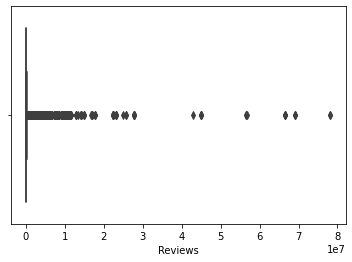

In [ ]:
sns.boxplot(df1['Reviews'])

- There are many outliers

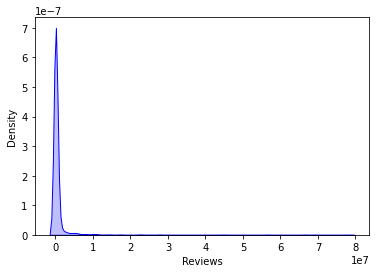

In [ ]:
sns.kdeplot(df1.Reviews, color="blue", shade = True)

In [ ]:
# Let's check samples having review less than 1000
df1[df1['Reviews'] < 1000].shape

(3466, 6)

In [ ]:
# Let's check samples having review more than 500000
df1[df1['Reviews'] > 500000].shape

(1036, 6)

In [ ]:
print(df1['Reviews'].max())
print(df1['Reviews'].min())

78158306
1


- We can see that the review feature is highly skewed. We can see that it has a very high range. 

## 1.2 Outlier treatment
- Remove/replace outliers beyond lower_whisker & upper_whisker

In [ ]:
# Using IQR method
Q1 = df1['Reviews'].quantile(0.25)
Q3 = df1['Reviews'].quantile(0.75)
IQR = Q3-Q1
print(Q1)
print(Q3)
print(IQR)

186.75
81627.5
81440.75


In [ ]:
lower_whisker  = Q1-(1.5*IQR)
upper_whisker  = Q3+(1.5*IQR)
print(lower_whisker)
print(upper_whisker)

-121974.375
203788.625


In [ ]:
df1_out = df1.loc[(df1['Reviews'] < upper_whisker) & (df1['Reviews'] > lower_whisker)] # rows without outliers
df1_out.shape

(7726, 6)

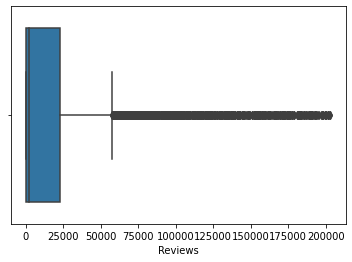

In [ ]:
sns.boxplot(df1_out.Reviews)

The IQR is very high so the lower_whisker and upper_whisker will be extreme in this case. 
Here, log transformation or z-score scaling would be preferred.

##### Conclusion
- We can see that there are still outliers in the second case
- Since the IQR is very high, we can go for log transformation in this case

--------
## Happy learning:)
--------